<h1>Capstone Project: The Impact of Weather on Flight Delays</h1>

<h2> Notebook 1 - Train Dataset</h2> 

<h2>1. Introduction/Project Context</h2> 

<h3>1.1 Define the problem or question - business application</h3> 


Flight delays are not just an inconvenience — they represent a multi-billion-dollar operational challenge for the aviation industry. In the U.S. alone, delays have been estimated to cost around $33 billion yearly. 

We came across <a href='https://ansperformance.eu/economics/cba/standard-inputs/latest/chapters/cost_of_delay.html'>a study</a> that indicates that a single 15 minute delay at gate for an Airbus A321 aircraft could cost an airline €689 as a base tactical cost, disregarding the chain reaction effect. If we are able to create a model that would predict five 15 minute delays a week for this type of aircraft, the avoided tactical cost alone could be approximately €180,000 annually — excluding downstream network effects.

There are various reasons as to why a flight could be delayed, could be carrier related, security, late aircraft arrival, etc.

The objective of this project is to examine the extent to which weather conditions influence the likelihood of flight departure delays and to develop a predictive model using combined flight and meteorological data.

Such a model could support operational stakeholders across the aviation ecosystem — including air traffic management, airlines, and ground operations — enabling earlier planning and helping minimise the downstream impact of delays. This could include crew planning, aircraft routing, gate allocation, and passenger reaccommodation.

The goal is to catch delayed flights whist also keeping an eye on the false positives as they also come at cost, so we will look at recall as well as average precision score for metrics

<h3>1.2 Find the Data</h3> 

For the project Individual csv files were downloaded from the United States Department of Transportation website, Bureau of Transportation Statistics, <a href='https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr'>‘On-Time: Reporting Carrier On-Time Performance (1987-present)'</a> webpage, with certain fields

Train set are 2022 - 2023 flight data, limited to John F. Kennedy International Airport (JFK). 261,001 observations with 33 columns (not all used) - covered in this notebook

Test set are January – October 2025 flight data, limited to JFK.  85,435 observations with 33 columns (not all used) - covered in notebook 2

Weather conditions at the scheduled departure time were added using Meteostat Python library

Delay is classified as departure from the gate 15 or more mins later than scheduled


<h2>2. Load & Explore Data </h2>

<h3>2.1. Load Data</h3>

In [1]:
# Data files sourced from BTS (see data/README.md)
# Paths reference local directory structure used during development
# Update paths to match your local setup if reproducing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.colors import LinearSegmentedColormap

from datetime import datetime
import meteostat as ms

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Set colour palette
palette = [
    "#4FA3C5",  # Glacier Lake Blue
    "#2E4259",  # Andean Slate
    "#7E9B6C",  # Moss Trail Green
    "#C7A76C",  # Autumn Grass
    "#D08159",  # Sunset Clay
    "#C9C5E0"   # Frost Lavender
]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#F9FAFB",
        "grid.color": "#E6E6E6",
        "figure.facecolor": "white",
        "axes.edgecolor": "#DDDDDD",
        "font.size": 12,
        "axes.titlepad": 12,
        "axes.labelpad": 8,
        "axes.titleweight": "bold",
    }
)

sns.set_palette(palette)

In [4]:
# Read 2022 CSVs
jan_22 = pd.read_csv('data/T_ONTIME_REPORTING_01_2022.csv')

feb_22 = pd.read_csv('data/T_ONTIME_REPORTING_02_2022.csv')

march_22 = pd.read_csv('data/T_ONTIME_REPORTING_03_2022.csv')

april_22 = pd.read_csv('data/T_ONTIME_REPORTING_04_2022.csv')

may_22 = pd.read_csv('data/T_ONTIME_REPORTING_05_2022.csv')

june_22 = pd.read_csv('data/T_ONTIME_REPORTING_06_2022.csv')

july_22 = pd.read_csv('data/T_ONTIME_REPORTING_07_2022.csv')

aug_22 = pd.read_csv('data/T_ONTIME_REPORTING_08_2022.csv')

sep_22 = pd.read_csv('data/T_ONTIME_REPORTING_09_2022.csv')

october_22 = pd.read_csv('data/T_ONTIME_REPORTING_10_2022.csv')

nov_22 = pd.read_csv('data/T_ONTIME_REPORTING_11_2022.csv')

dec_22 = pd.read_csv('data/T_ONTIME_REPORTING_12_2022.csv')

In [5]:
# Check 2022 cvs' shapes
print(jan_22.shape)
print(feb_22.shape)
print(march_22.shape)
print(april_22.shape)
print(may_22.shape)
print(june_22.shape)
print(july_22.shape)
print(aug_22.shape)
print(sep_22.shape)
print(october_22.shape)
print(nov_22.shape)
print(dec_22.shape)

(60603, 17)
(56366, 17)
(63612, 17)
(62410, 17)
(64499, 17)
(63613, 17)
(64982, 17)
(64692, 17)
(62506, 17)
(63705, 17)
(61936, 17)
(59922, 17)


In [6]:
# Spot check a 2022 csv
june_22.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,6/1/2022 12:00:00 AM,NaN,1209,11618,EWR,14576,ROC,1859,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
1,6/1/2022 12:00:00 AM,NaN,1501,12266,IAH,12953,LGA,1842,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,6/1/2022 12:00:00 AM,NaN,1513,12953,LGA,10397,ATL,2245,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
3,6/1/2022 12:00:00 AM,NaN,2231,13930,ORD,12953,LGA,2010,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,6/1/2022 12:00:00 AM,NaN,2642,13930,ORD,12953,LGA,1800,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN


In [7]:
# Read 2023 CSVs
jan_23 = pd.read_csv('data/T_ONTIME_REPORTING_01_2023.csv')

feb_23 = pd.read_csv('data/T_ONTIME_REPORTING_02_2023.csv')

march_23 = pd.read_csv('data/T_ONTIME_REPORTING_03_2023.csv')

april_23 = pd.read_csv('data/T_ONTIME_REPORTING_04_2023.csv')

may_23 = pd.read_csv('data/T_ONTIME_REPORTING_05_2023.csv')

june_23 = pd.read_csv('data/T_ONTIME_REPORTING_06_2023.csv')

july_23 = pd.read_csv('data/T_ONTIME_REPORTING_07_2023.csv')

aug_23 = pd.read_csv('data/T_ONTIME_REPORTING_08_2023.csv')

sep_23 = pd.read_csv('data/T_ONTIME_REPORTING_09_2023.csv')

october_23 = pd.read_csv('data/T_ONTIME_REPORTING_10_2023.csv')

nov_23 = pd.read_csv('data/T_ONTIME_REPORTING_11_2023.csv')

dec_23 = pd.read_csv('data/T_ONTIME_REPORTING_12_2023.csv')

In [8]:
# Check 2023 cvs' shapes
print(jan_23.shape)
print(feb_23.shape)
print(march_23.shape)
print(april_23.shape)
print(may_23.shape)
print(june_23.shape)
print(july_23.shape)
print(aug_23.shape)
print(sep_23.shape)
print(october_23.shape)
print(nov_23.shape)
print(dec_23.shape)

(59610, 17)
(57666, 17)
(65455, 17)
(62106, 17)
(63854, 17)
(60127, 17)
(60526, 17)
(62072, 17)
(59157, 17)
(61524, 17)
(58924, 17)
(56825, 17)


In [9]:
# Spot check a 2023 csv
dec_23.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,12/1/2023 12:00:00 AM,208NV,884,14082,PGD,12265,IAG,1559,1619.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0
1,12/1/2023 12:00:00 AM,208NV,908,12265,IAG,14082,PGD,1937,2004.0,27.0,0.0,0.0,9.0,0.0,0.0,0.0,7.0
2,12/1/2023 12:00:00 AM,217NV,1279,11537,ELM,14761,SFB,1206,1155.0,-11.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,12/1/2023 12:00:00 AM,217NV,2865,14761,SFB,11537,ELM,845,831.0,-14.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,12/1/2023 12:00:00 AM,230NV,1073,14025,PBG,14112,PIE,1046,1033.0,-13.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [10]:
# Merge all 24 datasets
df = pd.concat(
    [jan_22, feb_22, march_22, april_22, may_22, june_22, july_22, aug_22, sep_22,october_22, nov_22, dec_22, 
    jan_23, feb_23, march_23, april_23, may_23, june_23, july_23, aug_23, sep_23, october_23, nov_23, dec_23], axis=0, ignore_index=True)

In [11]:
# Shape
df.shape

(1476692, 17)

In [12]:
# Head
df.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,1/1/2022 0:00,NaN,1092,13204,MCO,12391,ISP,2205,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
1,1/1/2022 0:00,NaN,1095,12391,ISP,13204,MCO,600,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,1/1/2022 0:00,NaN,1215,15096,SYR,13204,MCO,1044,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
3,1/1/2022 0:00,NaN,1400,13930,ORD,10792,BUF,1805,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,1/1/2022 0:00,NaN,1428,12953,LGA,13232,MDW,600,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN


In [13]:
df.sample(7)

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
1245507,9/3/2023 12:00:00 AM,N919DU,547,12478,JFK,14057,PDX,1859,1859.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
778852,1/17/2023 12:00:00 AM,N438YX,4331,12478,JFK,11193,CVG,825,818.0,-7.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
38724,1/20/2022 12:00:00 AM,N899SK,3846,14576,ROC,11433,DTW,953,1039.0,46.0,0.0,0.0,56.0,0.0,0.0,0.0,0.0
856509,2/24/2023 12:00:00 AM,N299PQ,5376,14685,SAV,12953,LGA,624,622.0,-2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
728172,12/19/2022 12:00:00 AM,N931NN,2961,12953,LGA,11298,DFW,1353,1349.0,-4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1207261,8/15/2023 12:00:00 AM,N516JB,1371,12953,LGA,11697,FLL,601,559.0,-2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1054811,5/30/2023 12:00:00 AM,N804AW,2992,14492,RDU,12953,LGA,1909,1858.0,-11.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [14]:
# Limit the dataset to JFK only
df = df[df['ORIGIN'] == 'JFK'].copy()

<h3>2.2. Explore and Clean the Data</h3>

In [15]:
#replace spaces in the column names with an underscore
df.columns = [d.replace(' ', '_') for d in df.columns.str.lower()] 

In [16]:
df.columns.tolist()

['fl_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [17]:
# Assign a new list of column names for more context on what's in them
df = df.rename(columns={
    'fl_date': 'flight_date',
    'fl_date': 'flight_date'
})                

In [18]:
# Check results
df.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [19]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269629 entries, 11 to 1476691
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   flight_date          269629 non-null  object 
 1   tail_num             269512 non-null  object 
 2   op_carrier_fl_num    269629 non-null  int64  
 3   origin_airport_id    269629 non-null  int64  
 4   origin               269629 non-null  object 
 5   dest_airport_id      269629 non-null  int64  
 6   dest                 269629 non-null  object 
 7   crs_dep_time         269629 non-null  int64  
 8   dep_time             262101 non-null  float64
 9   dep_delay            262101 non-null  float64
 10  cancelled            269629 non-null  float64
 11  diverted             269629 non-null  float64
 12  carrier_delay        64380 non-null   float64
 13  weather_delay        64380 non-null   float64
 14  nas_delay            64380 non-null   float64
 15  security_delay      

In [20]:
# Check if the dep_delay column has correct values
df.iloc[:, 7:].sample(10)

,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
152924,715,704.0,-11.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1040394,930,923.0,-7.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
259562,1130,1127.0,-3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
967622,650,640.0,-10.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1020321,800,756.0,-4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
67900,1040,1039.0,-1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1112342,1000,959.0,-1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1324550,1530,1544.0,14.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1135336,926,927.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
216323,2245,2320.0,35.0,0.0,0.0,26.0,0.0,34.0,0.0,9.0


In [21]:
# Count the number of unique values in a DataFrame or Series. 
# we can identify the continuous and categorical columns in the data
df.nunique() 

flight_date             730
tail_num               2608
op_carrier_fl_num      2124
origin_airport_id         1
origin                    1
dest_airport_id          74
dest                     74
crs_dep_time            956
dep_time               1373
dep_delay               854
cancelled                 2
diverted                  2
carrier_delay           674
weather_delay           325
nas_delay               412
security_delay           81
late_aircraft_delay     440
dtype: int64

In [22]:
# Check Null Values
df.isnull().sum()

flight_date                 0
tail_num                  117
op_carrier_fl_num           0
origin_airport_id           0
origin                      0
dest_airport_id             0
dest                        0
crs_dep_time                0
dep_time                 7528
dep_delay                7528
cancelled                   0
diverted                    0
carrier_delay          205249
weather_delay          205249
nas_delay              205249
security_delay         205249
late_aircraft_delay    205249
dtype: int64

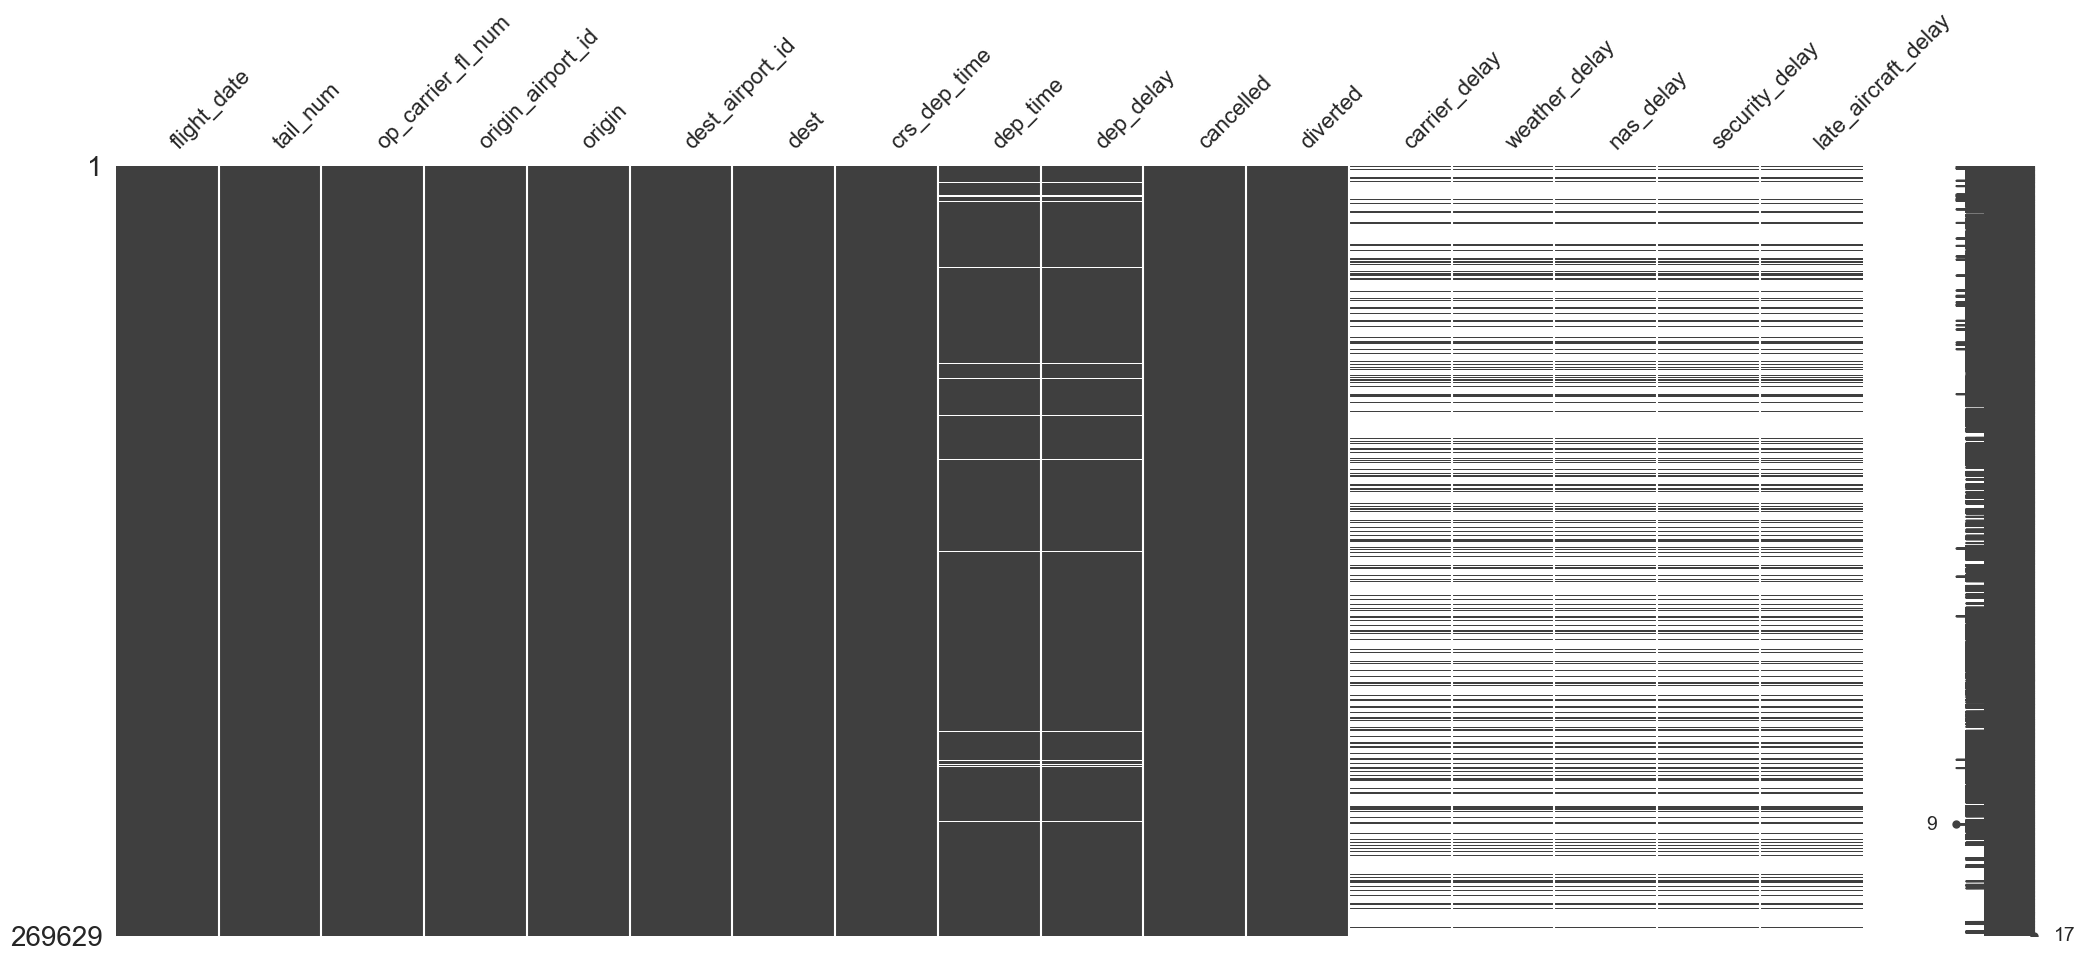

In [23]:
# Check Null Values
msno.matrix(df)
plt.show()

In [24]:
df['carrier_delay'] = df['carrier_delay'].fillna(0) # Replaces all NaNs with 0
df['weather_delay'] = df['weather_delay'].fillna(0) # Replaces all NaNs with 0
df['nas_delay'] = df['nas_delay'].fillna(0) # Replaces all NaNs with 0
df['security_delay'] = df['security_delay'].fillna(0) # Replaces all NaNs with 0
df['late_aircraft_delay'] = df['late_aircraft_delay'].fillna(0) # Replaces all NaNs with 0

In [25]:
# Check if the dep_delay column has correct values
df.loc[1354962]

flight_date            10/29/2023 12:00:00 AM
tail_num                               N120DN
op_carrier_fl_num                        2170
origin_airport_id                       12478
origin                                    JFK
dest_airport_id                         13204
dest                                      MCO
crs_dep_time                             1525
dep_time                               1522.0
dep_delay                                -3.0
cancelled                                 0.0
diverted                                  0.0
carrier_delay                             0.0
weather_delay                             0.0
nas_delay                                 0.0
security_delay                            0.0
late_aircraft_delay                       0.0
Name: 1354962, dtype: object

In [26]:
# Recheck missing values
df.isnull().sum()

flight_date               0
tail_num                117
op_carrier_fl_num         0
origin_airport_id         0
origin                    0
dest_airport_id           0
dest                      0
crs_dep_time              0
dep_time               7528
dep_delay              7528
cancelled                 0
diverted                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
dtype: int64

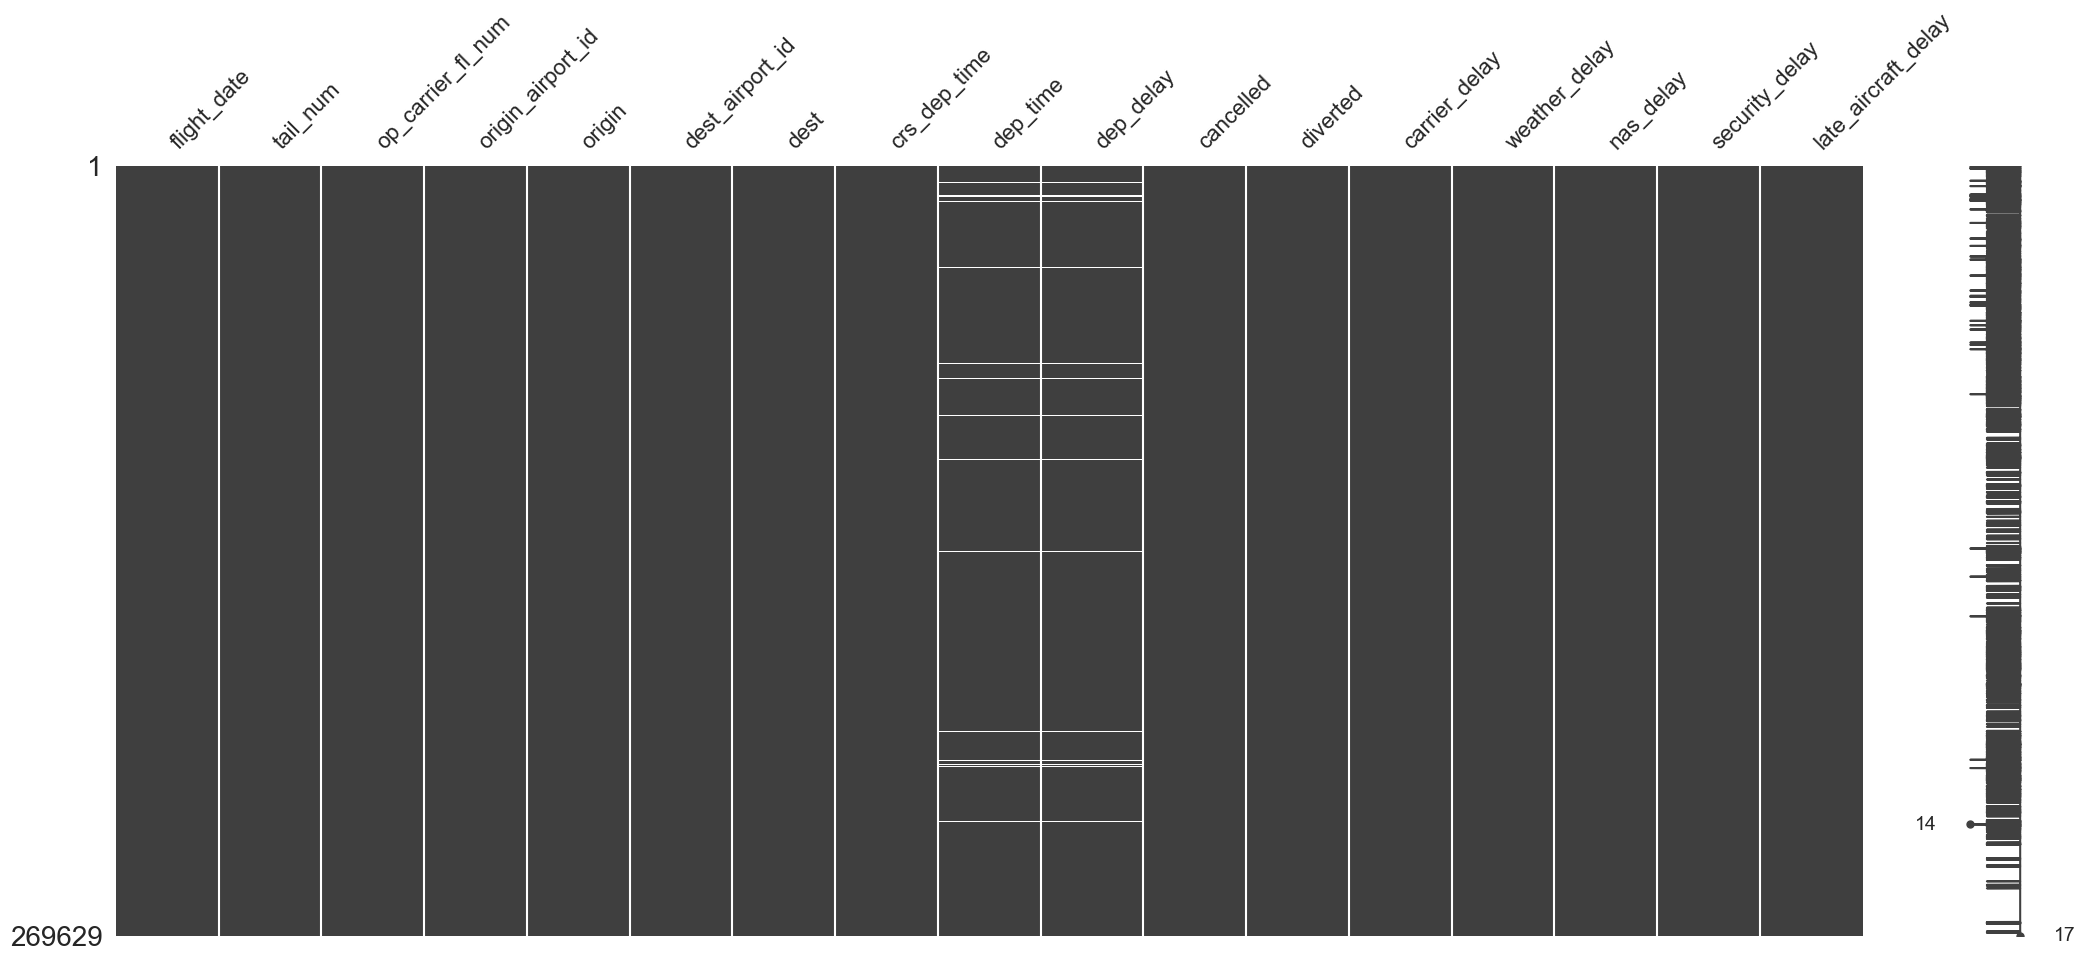

In [27]:
# Recheck missing values
msno.matrix(df)
plt.show()

In [28]:
# Drop rows with any NaN value since these are departure information, cannot impute that
df = df.dropna()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262101 entries, 21 to 1476691
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   flight_date          262101 non-null  object 
 1   tail_num             262101 non-null  object 
 2   op_carrier_fl_num    262101 non-null  int64  
 3   origin_airport_id    262101 non-null  int64  
 4   origin               262101 non-null  object 
 5   dest_airport_id      262101 non-null  int64  
 6   dest                 262101 non-null  object 
 7   crs_dep_time         262101 non-null  int64  
 8   dep_time             262101 non-null  float64
 9   dep_delay            262101 non-null  float64
 10  cancelled            262101 non-null  float64
 11  diverted             262101 non-null  float64
 12  carrier_delay        262101 non-null  float64
 13  weather_delay        262101 non-null  float64
 14  nas_delay            262101 non-null  float64
 15  security_delay      

In [30]:
# Fix the  dep_time  column type
df['dep_time'] = df['dep_time'].astype('float64')
df['dep_time'] = df['dep_time'].astype('int64')

In [31]:
# Fix the dep_delay column type
df['dep_delay'] = df['dep_delay'].astype('int64')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262101 entries, 21 to 1476691
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   flight_date          262101 non-null  object 
 1   tail_num             262101 non-null  object 
 2   op_carrier_fl_num    262101 non-null  int64  
 3   origin_airport_id    262101 non-null  int64  
 4   origin               262101 non-null  object 
 5   dest_airport_id      262101 non-null  int64  
 6   dest                 262101 non-null  object 
 7   crs_dep_time         262101 non-null  int64  
 8   dep_time             262101 non-null  int64  
 9   dep_delay            262101 non-null  int64  
 10  cancelled            262101 non-null  float64
 11  diverted             262101 non-null  float64
 12  carrier_delay        262101 non-null  float64
 13  weather_delay        262101 non-null  float64
 14  nas_delay            262101 non-null  float64
 15  security_delay      

In [33]:
# Check the percentage of cancelled flights
df['cancelled'].value_counts(normalize=True)

cancelled
0.0    0.99847
1.0    0.00153
Name: proportion, dtype: float64

In [34]:
# Check the percentage of diverted flights
df['diverted'].value_counts(normalize=True)

diverted
0.0    0.997333
1.0    0.002667
Name: proportion, dtype: float64

In [35]:
df.nlargest(5, 'dep_delay')

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
971460,4/20/2023 12:00:00 AM,N153UW,892,12478,JFK,11057,CLT,619,926,1627,0.0,0.0,1627.0,0.0,6.0,0.0,0.0
991959,4/30/2023 12:00:00 AM,N191UW,2624,12478,JFK,11057,CLT,1617,1818,1561,0.0,0.0,1040.0,0.0,0.0,0.0,501.0
1257301,9/10/2023 12:00:00 AM,N113AN,331,12478,JFK,12892,LAX,1100,949,1369,0.0,0.0,1040.0,0.0,21.0,0.0,329.0
1152047,7/18/2023 12:00:00 AM,N922NN,2423,12478,JFK,11298,DFW,1559,1439,1360,0.0,0.0,897.0,0.0,0.0,0.0,448.0
1256218,9/9/2023 12:00:00 AM,N322SY,3941,12478,JFK,13342,MKE,1730,1552,1342,0.0,0.0,1323.0,0.0,0.0,0.0,0.0


In [36]:
df.nlargest(5, 'weather_delay')

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
65593,2/3/2022 12:00:00 AM,N349PQ,5043,12478,JFK,11042,CLE,1855,1335,1120,0.0,0.0,0.0,1101.0,0.0,0.0,0.0
1155059,7/20/2023 12:00:00 AM,N322SY,4031,12478,JFK,13930,ORD,1610,954,1064,0.0,0.0,0.0,1079.0,0.0,0.0,0.0
770587,1/13/2023 12:00:00 AM,N261SY,3945,12478,JFK,13930,ORD,1600,850,1010,0.0,0.0,0.0,1012.0,0.0,0.0,0.0
523440,9/12/2022 12:00:00 AM,N121HQ,4687,12478,JFK,11278,DCA,1540,817,997,0.0,0.0,0.0,993.0,13.0,0.0,4.0
1166126,7/25/2023 12:00:00 AM,N935XJ,5304,12478,JFK,10821,BWI,1455,657,962,0.0,0.0,0.0,962.0,3.0,0.0,0.0


In [37]:
# Drop cancelled and diverted flights (for now)
df = df[(df["cancelled"] == 0) & (df["diverted"] == 0)].copy()

<b>Observations:</b>
- The dataset is a combination of individual csvs, filtered to JFK.
- Fairly clean column names, renamed ‘flight_date’ column and some data types
- Identified the null values and approached them in various ways: some were filled with 0 where possible, others dropped

<h3>2.3. Add Weather Data</h3>

In [38]:
# Ensure fl_date is string
df['flight_date'] = df['flight_date'].astype(str)

In [39]:
# convert 1347 → "13:47"
df["crs_dep_time"] = df["crs_dep_time"].astype(str).str.zfill(4)
df["dep_time"] = df["dep_time"].astype(str).str.zfill(4)

In [40]:
# Helper to build datetime from date + HHMM string
def build_datetime(date_col, time_col):
    return pd.to_datetime(
        df[date_col] + " " +
        df[time_col].str.slice(0, 2) + ":" +
        df[time_col].str.slice(2, 4),
        errors="coerce"
    )

In [41]:
# Create scheduled departure datetimes (local airport time) - for weather
df["scheduled_dep_dt"] = build_datetime("flight_date", "crs_dep_time")

In [42]:
# Check the date and time have been merged correctly
df[["flight_date", "crs_dep_time", "scheduled_dep_dt"]].sample(5)

,flight_date,crs_dep_time,scheduled_dep_dt
890724,3/12/2023 12:00:00 AM,1829,2023-03-12 18:29:00
1119824,7/2/2023 12:00:00 AM,1528,2023-07-02 15:28:00
983063,4/25/2023 12:00:00 AM,0620,2023-04-25 06:20:00
1392908,11/16/2023 12:00:00 AM,0800,2023-11-16 08:00:00
640466,11/7/2022 12:00:00 AM,0818,2022-11-07 08:18:00


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261001 entries, 21 to 1476691
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   flight_date          261001 non-null  object        
 1   tail_num             261001 non-null  object        
 2   op_carrier_fl_num    261001 non-null  int64         
 3   origin_airport_id    261001 non-null  int64         
 4   origin               261001 non-null  object        
 5   dest_airport_id      261001 non-null  int64         
 6   dest                 261001 non-null  object        
 7   crs_dep_time         261001 non-null  object        
 8   dep_time             261001 non-null  object        
 9   dep_delay            261001 non-null  int64         
 10  cancelled            261001 non-null  float64       
 11  diverted             261001 non-null  float64       
 12  carrier_delay        261001 non-null  float64       
 13  weather_delay    

In [44]:
# 1. Make sure sched_dep_dt exists and looks sane
print(df['scheduled_dep_dt'].min(), df['scheduled_dep_dt'].max())

2022-01-01 05:40:00 2023-12-31 23:25:00


In [45]:
2 # Define the station ID
station_id = '74486' #John F. Kennedy International Airport (JFK)

# Convert start/end to plain Python datetimes (not pandas Timestamps)
start = df["scheduled_dep_dt"].min().to_pydatetime()
end   = df["scheduled_dep_dt"].max().to_pydatetime()

print("Start:", start, "End:", end)

Start: 2022-01-01 05:40:00 End: 2023-12-31 23:25:00


In [46]:
# 3. Fetch daily weather data
weather_data = ms.hourly(station_id, start, end)
weather_data = weather_data.fetch()

In [47]:
# 4. Display the first few rows of the DataFrame
if not weather_data.empty:
    print(weather_data.sample(10))
else:
    print("No data found for the specified station and time period.")

                     temp  rhum  prcp  snwd  wdir  wspd  wpgt    pres  tsun  \
time                                                                          
2023-05-05 10:00:00   7.2    97   0.0  <NA>    40   9.4  <NA>  1020.2  <NA>   
2023-03-01 12:00:00  -0.6    85   0.0  <NA>    20   9.4  <NA>  1020.9  <NA>   
2023-01-05 13:00:00   8.9   100   0.0  <NA>    60   9.4  <NA>  1014.1  <NA>   
2022-10-22 20:00:00  17.2    43   0.0  <NA>   160   9.4  <NA>  1024.9  <NA>   
2023-08-06 00:00:00  26.7    45   0.0  <NA>   360  14.8  <NA>  1014.8  <NA>   
2023-04-22 07:00:00  11.7    96   0.0  <NA>    60  14.8  <NA>  1015.0  <NA>   
2022-02-21 04:00:00   0.6    66   0.0  <NA>   210  25.9  <NA>  1027.9  <NA>   
2023-02-24 23:00:00   2.2    38   0.0  <NA>   320  31.7  <NA>  1029.5  <NA>   
2022-03-18 20:00:00  13.9    77   0.0  <NA>   180  14.8  <NA>  1016.1  <NA>   
2023-08-25 18:00:00  24.4    88   0.0  <NA>   180  27.7  <NA>  1011.5  <NA>   

                     cldc  coco  
time             

In [48]:
#5 Reset index so 'time' becomes a column
weather_data = weather_data.reset_index().rename(columns={"time": "weather_time"})

In [49]:
#6 Sort both
df = df.sort_values('scheduled_dep_dt')
weather_data = weather_data.sort_values('weather_time')

In [50]:
#7 Merge the weather data with the flights data on scheduled departure time and date column
merged_df = pd.merge_asof(
    df,
    weather_data,
    left_on='scheduled_dep_dt',
    right_on='weather_time',
    direction='nearest',
    tolerance=pd.Timedelta('1h')
)

In [51]:
merged_df.shape

(261001, 30)

In [52]:
# Removes rows where the weather join failed
merged_df = merged_df.dropna(subset=['weather_time']).copy()

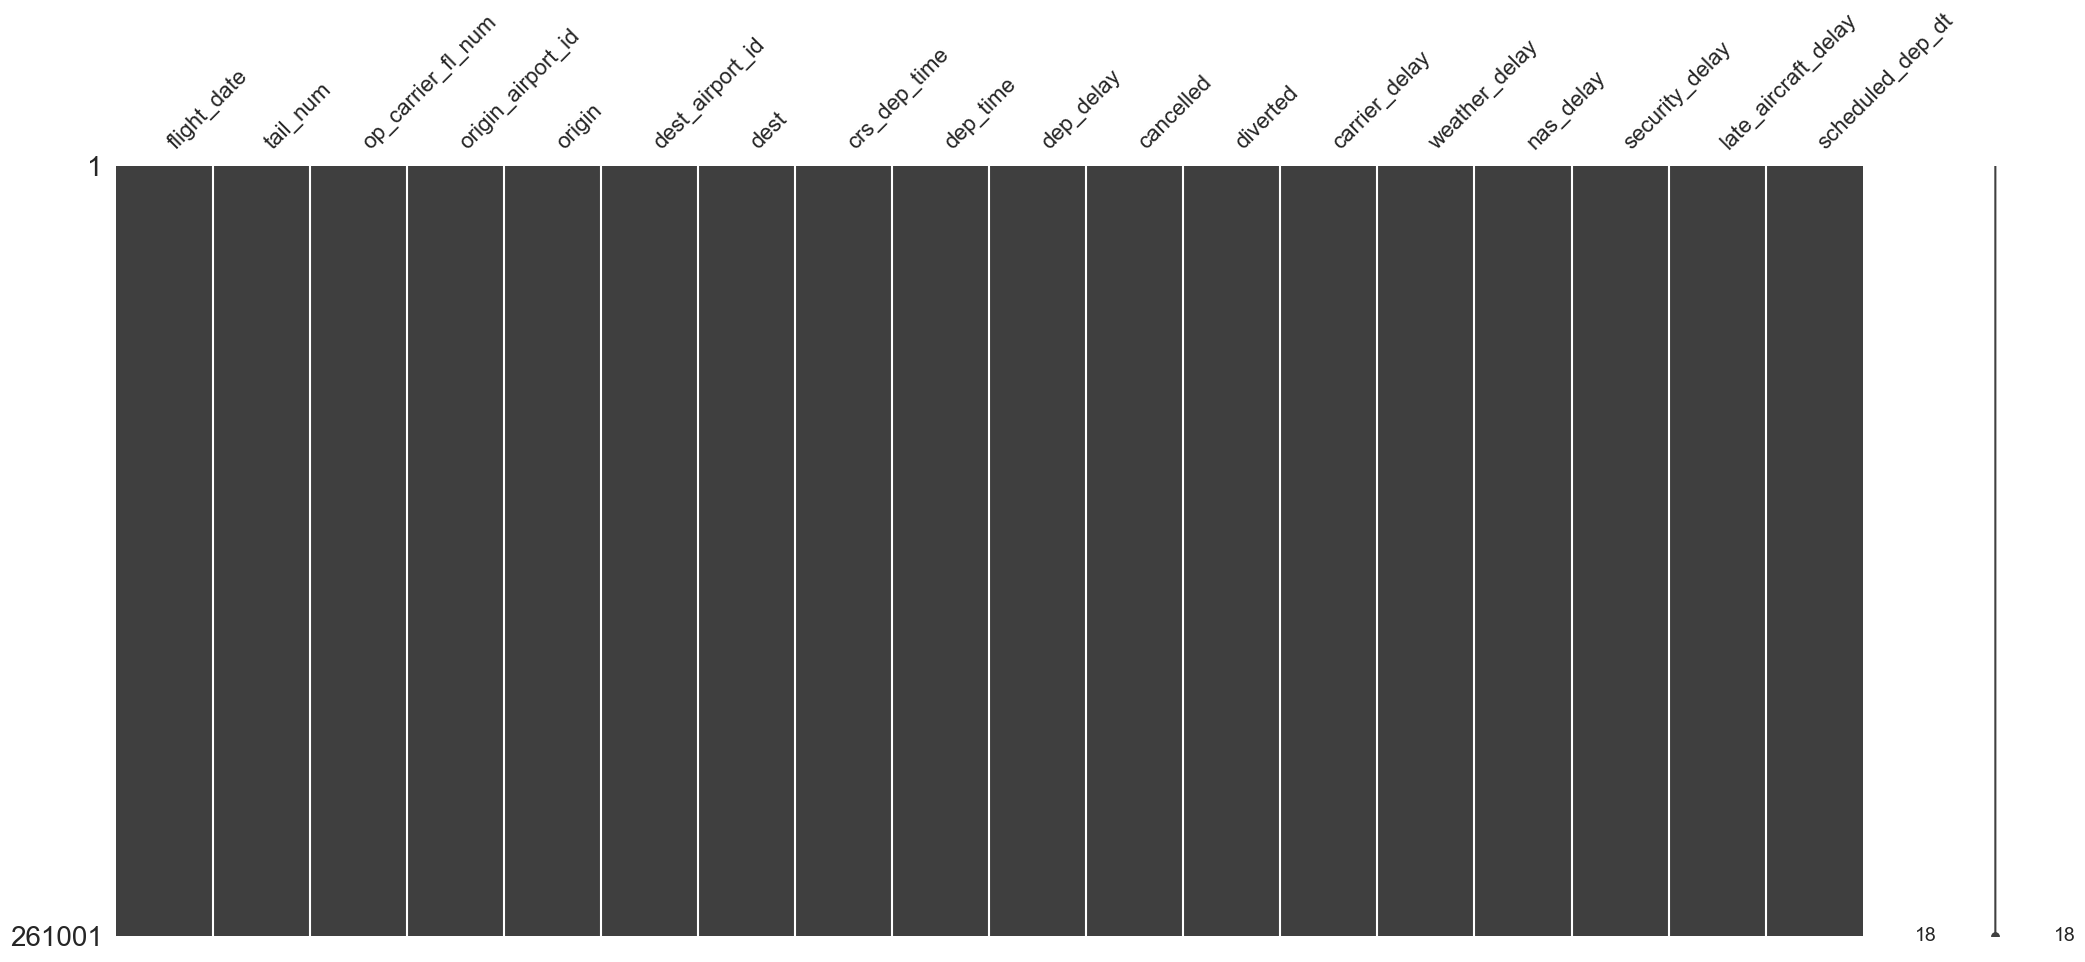

In [53]:
# Recheck missing values
msno.matrix(df)
plt.show()

In [54]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261001 entries, 0 to 261000
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   flight_date          261001 non-null  object        
 1   tail_num             261001 non-null  object        
 2   op_carrier_fl_num    261001 non-null  int64         
 3   origin_airport_id    261001 non-null  int64         
 4   origin               261001 non-null  object        
 5   dest_airport_id      261001 non-null  int64         
 6   dest                 261001 non-null  object        
 7   crs_dep_time         261001 non-null  object        
 8   dep_time             261001 non-null  object        
 9   dep_delay            261001 non-null  int64         
 10  cancelled            261001 non-null  float64       
 11  diverted             261001 non-null  float64       
 12  carrier_delay        261001 non-null  float64       
 13  weather_delay 

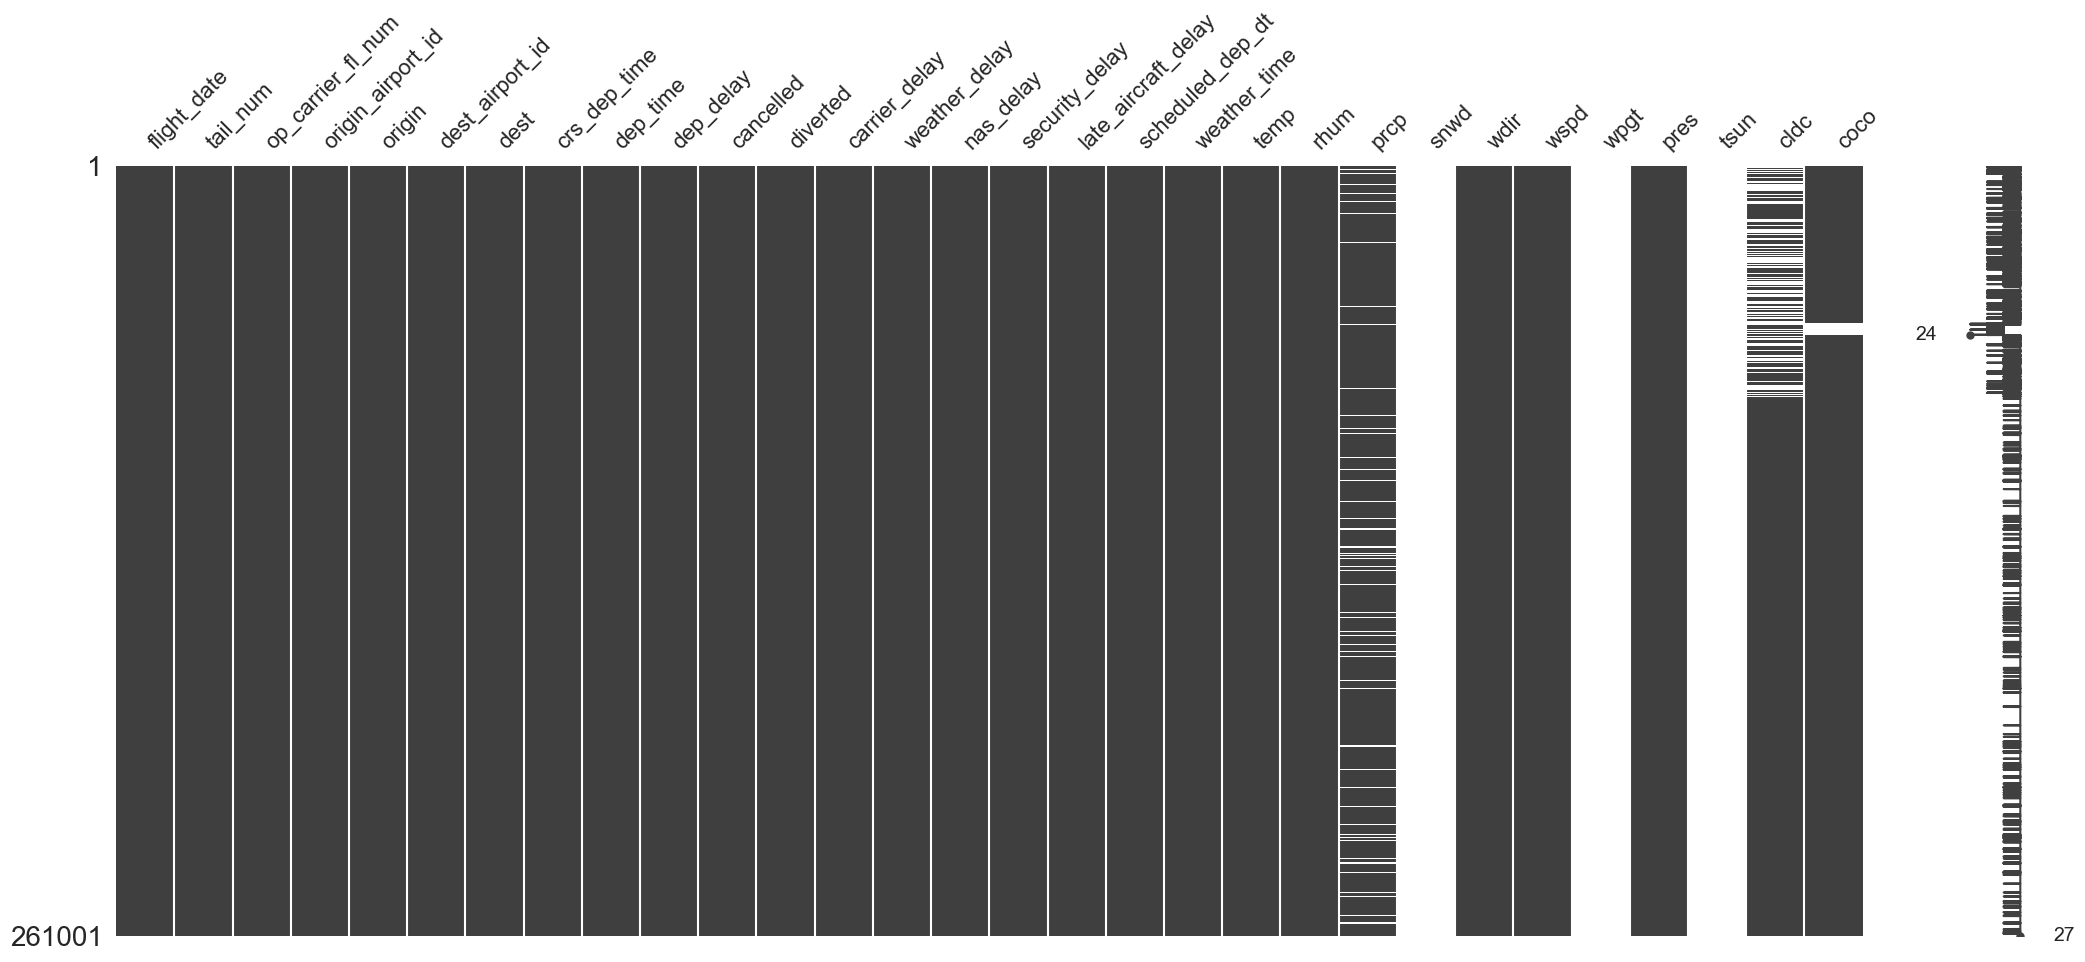

In [55]:
# Check Null Values
msno.matrix(merged_df)
plt.show()

In [56]:
# Merge quality check - how far off is the matched weather to the scheduled departure time
(merged_df['scheduled_dep_dt'] - merged_df['weather_time']).abs().describe()

count                       261001
mean     0 days 00:14:12.625009099
std      0 days 00:11:30.787907155
min                0 days 00:00:00
25%                0 days 00:01:00
50%                0 days 00:15:00
75%                0 days 00:25:00
max                0 days 00:30:00
dtype: object

<b>Observations: </b>
- Most flights are matched within ~15 minutes of weather data.
- Worst case is 30 minutes.
- Match has gone well 

<h3>2.4. Clean Weather Data</h3>

In [57]:
# Separate the weather data and check what's in it
cols = [
    'temp', 
    'rhum',
    'prcp',
    'snwd',
    'wdir',
    'wspd',
    'wpgt',
    'pres',
    'tsun',
    'cldc',
    'coco'
]

In [58]:
for col in merged_df[cols]:
    print(col, ': ', merged_df[col].unique(), '\n')

temp :  <FloatingArray>
[ 9.4, 10.0, 10.6, 11.1, 11.7, 12.2, 13.9, 14.4,  8.9,  3.3,
 ...
  8.0, 17.0, 23.0, 19.0, 14.0,  9.0,  6.0, 18.0, 11.0, 24.0]
Length: 109, dtype: Float64 

rhum :  <IntegerArray>
[ 97, 100,  96,  87,  81,  80,  86,  66,  62,  59,  54,  58,  56,  51,  49,
  41,  44,  46,  48,  53,  50,  60,  57,  52,  45,  75,  78,  79,  72,  85,
  88,  92,  93,  89,  82,  40,  37,  42,  69,  61,  47,  55,  39,  36,  31,
  63,  64,  67,  70,  73,  76,  83,  43,  38,  33,  35,  34,  32,  65,  68,
  30,  28,  25,  29,  74,  77,  27,  84,  71,  90,  23,  20,  21,  22,  24,
  19,  18,  16,  13,  12,  14,  26,  17,  11,  15,  94,  91]
Length: 87, dtype: UInt8 

prcp :  <FloatingArray>
[ 0.0,  0.3, <NA>,  1.3,  0.5,  0.8,  1.0,  2.3,  1.5,  1.8,  4.6,  4.3,  2.0,
  4.1,  6.4,  3.6,  2.8,  2.5,  3.8,  3.3,  3.0,  6.6,  6.1,  0.2,  1.2,  5.8,
  7.4, 10.4, 10.2,  4.8,  9.7,  6.9,  7.1,  0.1,  8.6,  0.7,  4.5,  2.2,  2.7,
  9.1, 10.9,  5.6,  8.1,  0.6,  5.1,  0.9,  7.9,  7.6,  5.3,  8.4, 

COCO - Weather Condition Codes
Hourly weather data may include information on the observed weather condition. Please note that the weather condition is not a key parameter for Meteostat. METAR reports, issued by weather stations located at airports, only report significant weather events. Also, some weather stations do not provide weather condition data at all.

<a href="https://dev.meteostat.net/formats.html" >More information on Coco</a>

<a href="https://dev.meteostat.net/parameters" >More information on Meteorological Parameters</a>

In [59]:
# 'snwd', 'wpgt' and 'tsun' is empty so can drop it
columns_to_drop = ['snwd', 'wpgt', 'tsun']
merged_df.drop(columns=columns_to_drop, axis=1, inplace=True)
merged_df.head()

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,scheduled_dep_dt,weather_time,temp,rhum,prcp,wdir,wspd,pres,cldc,coco
0,1/1/2022 0:00,N2047J,1603,12478,JFK,14843,SJU,0540,0954,254,...,2022-01-01 05:40:00,2022-01-01 06:00:00,9.4,97,0.0,180,13.0,1013.0,8,4
1,1/1/2022 0:00,N521JB,225,12478,JFK,15304,TPA,0600,0605,5,...,2022-01-01 06:00:00,2022-01-01 06:00:00,9.4,97,0.0,180,13.0,1013.0,8,4
2,1/1/2022 0:00,N969NN,2643,12478,JFK,11057,CLT,0600,0635,35,...,2022-01-01 06:00:00,2022-01-01 06:00:00,9.4,97,0.0,180,13.0,1013.0,8,4
3,1/1/2022 0:00,N4058J,23,12478,JFK,12892,LAX,0600,0619,19,...,2022-01-01 06:00:00,2022-01-01 06:00:00,9.4,97,0.0,180,13.0,1013.0,8,4
4,1/1/2022 0:00,N858NW,424,12478,JFK,10397,ATL,0610,0747,97,...,2022-01-01 06:10:00,2022-01-01 06:00:00,9.4,97,0.0,180,13.0,1013.0,8,4


In [60]:
# Check for NaN values
merged_df.isna().sum()

flight_date                0
tail_num                   0
op_carrier_fl_num          0
origin_airport_id          0
origin                     0
dest_airport_id            0
dest                       0
crs_dep_time               0
dep_time                   0
dep_delay                  0
cancelled                  0
diverted                   0
carrier_delay              0
weather_delay              0
nas_delay                  0
security_delay             0
late_aircraft_delay        0
scheduled_dep_dt           0
weather_time               0
temp                       0
rhum                       0
prcp                   15540
wdir                       0
wspd                       0
pres                       0
cldc                   33518
coco                    3736
dtype: int64

In [61]:
# filling missing Total Precipitation data
merged_df['prcp'] = merged_df['prcp'].fillna(0)

In [62]:
# Filling missing data cloud cover with a median but add a flag it was imputed
merged_df['cldc_missing'] = merged_df['cldc'].isna().astype(int)

merged_df['cldc'] = merged_df['cldc'].fillna(
    merged_df['cldc'].median()
)

In [63]:
# fill missing data
merged_df['coco'] = merged_df['coco'].fillna(0)

In [64]:
# Check for NaN values
merged_df.isna().sum()

flight_date            0
tail_num               0
op_carrier_fl_num      0
origin_airport_id      0
origin                 0
dest_airport_id        0
dest                   0
crs_dep_time           0
dep_time               0
dep_delay              0
cancelled              0
diverted               0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
scheduled_dep_dt       0
weather_time           0
temp                   0
rhum                   0
prcp                   0
wdir                   0
wspd                   0
pres                   0
cldc                   0
coco                   0
cldc_missing           0
dtype: int64

Since The United States Federal Aviation Administration (FAA) considers a flight to be delayed when it is 15 minutes later than its scheduled time, we will create a new column with 0 for no delay and 1 for delay when  dep_delay is over 15 mins 

In [65]:
# Create a new column with 0 for no delay and 1 for delay when delayed for 15 or more mins
# target column
merged_df['delayed_15'] = (merged_df['dep_delay'] >= 15).astype(int)

In [66]:
# Check what the target column looks like
merged_df.sample(5)

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,temp,rhum,prcp,wdir,wspd,pres,cldc,coco,cldc_missing,delayed_15
19979,3/1/2022 12:00:00 AM,N696DL,1547,12478,JFK,15024,STT,0830,0825,-5,...,-1.7,53,0.0,60,7.6,1026.2,5,4,1,0
232584,10/10/2023 12:00:00 AM,N931NN,688,12478,JFK,13303,MIA,1030,1027,-3,...,11.7,83,0.0,270,13.0,1009.9,4,4,0,0
142541,2/1/2023 12:00:00 AM,N184JB,486,12478,JFK,14576,ROC,2220,2239,19,...,2.8,35,0.0,270,20.5,1023.8,2,2,0,1
28745,3/25/2022 12:00:00 AM,N595JB,2062,12478,JFK,14027,PBI,1359,1413,14,...,9.4,83,0.0,200,13.0,1004.3,5,3,1,0
40517,4/27/2022 12:00:00 AM,N358NW,2957,12478,JFK,13495,MSY,1524,1522,-2,...,12.8,35,0.0,300,29.5,1013.5,4,3,0,0


In [67]:
# Check what is the proportion of delayed flights after data clean
merged_df['delayed_15'].value_counts(normalize=True)*100

delayed_15
0    75.64607
1    24.35393
Name: proportion, dtype: float64

<b>Observations:</b>
- created a ‘scheduled departure time’ column that combined the flight date with scheduled departure time columns and the values in the new column are in the datetime64[ns] format.
- added meteorological data in using Meteostat Python library based on the scheduled departure time, hourly, for station_id = '74486' #John F. Kennedy International Airport (JFK). Most flights are matched within  approx. 15 minutes of weather data, with the worst case being 30 minutes for the train set
- dropped any rows with missing weather data, then checked the null values and dropped  'snwd', 'wpgt', 'tsun' since there were unfortunately no observations in these columns
- In terms of any missing weather related values:
    - ‘prcp’ was missing 15537, fill with a 0
    - for the ‘cldc’, we created a new column indicating data was missing, then filled the missing data with the median of ‘cldc’
    - for ‘coco’, fill any missing data with 0 - it’s not a category as such, since ‘coco’ is a categorical value from 1 to 27. 
- Once the data was cleaned, we created our target variable column, ‘delayed_15’, based on the ‘departure delay’ column, by assigning 1 for ‘delay’ for those observations where the departure delay is equal or over 15 mins.


<h2>3. Perform Exploratory Data Analysis (EDA)</h2>

In [68]:
merged_df.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'scheduled_dep_dt',
 'weather_time',
 'temp',
 'rhum',
 'prcp',
 'wdir',
 'wspd',
 'pres',
 'cldc',
 'coco',
 'cldc_missing',
 'delayed_15']

In [69]:
# Separate continuous features for EDA
continuous_features = [
    'temp',
    'rhum',
    'prcp',
    'wspd',
    'pres',
    'dep_delay'
]

In [70]:
# Just weather continious features
weather_features = ['temp', 'rhum', 'prcp', 'wspd', 'pres']

In [71]:
# cloud cover: 0–8 octas. 0 oktas represents the complete absence of cloud. 8 oktas represents full cloud cover with no breaks.
ordinal_features = [
    'cldc' 
]

In [72]:
# Wind direction is not linear
# The average wind direction in degrees (°)
circular_features = [
    'wdir'
]

In [73]:
# a weather condition code, not a magnitude.
categorical_features = [
    'coco'
]

In [74]:
#statistical summary of the DataFrame (Transpose) 
merged_df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,261001.0,13.4028,9.124129,-15.0,6.1,13.3,21.1,35.0
rhum,261001.0,67.015019,20.191253,11.0,51.0,67.0,84.0,100.0
prcp,261001.0,0.111344,0.800417,0.0,0.0,0.0,0.0,31.2
wspd,261001.0,18.145338,9.472275,0.0,11.2,16.6,24.1,64.8
pres,261001.0,1016.918879,8.04015,982.9,1011.9,1016.8,1022.2,1041.4
dep_delay,261001.0,16.535147,56.927069,-50.0,-5.0,-2.0,14.0,1627.0


In [75]:
# Correlation
merged_df_corr = merged_df[continuous_features].corr(numeric_only=True) 
merged_df_corr

,temp,rhum,prcp,wspd,pres,dep_delay
temp,1.000000,0.036510,-0.007747,-0.102014,-0.299247,0.062328
rhum,0.036510,1.000000,0.194115,-0.322664,-0.235611,0.025883
prcp,-0.007747,0.194115,1.000000,0.066725,-0.102954,0.041730
wspd,-0.102014,-0.322664,0.066725,1.000000,-0.219104,0.059401
pres,-0.299247,-0.235611,-0.102954,-0.219104,1.000000,-0.072317
dep_delay,0.062328,0.025883,0.041730,0.059401,-0.072317,1.000000


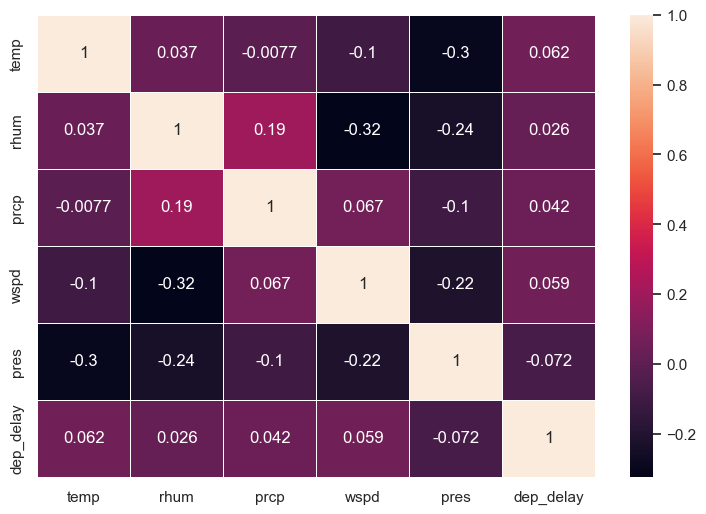

In [76]:
# Create the heatmap
plt.figure(figsize=(9, 6)) # Optional: adjust the size
sns.heatmap(merged_df_corr, annot=True, linewidths=.5) 
plt.show()

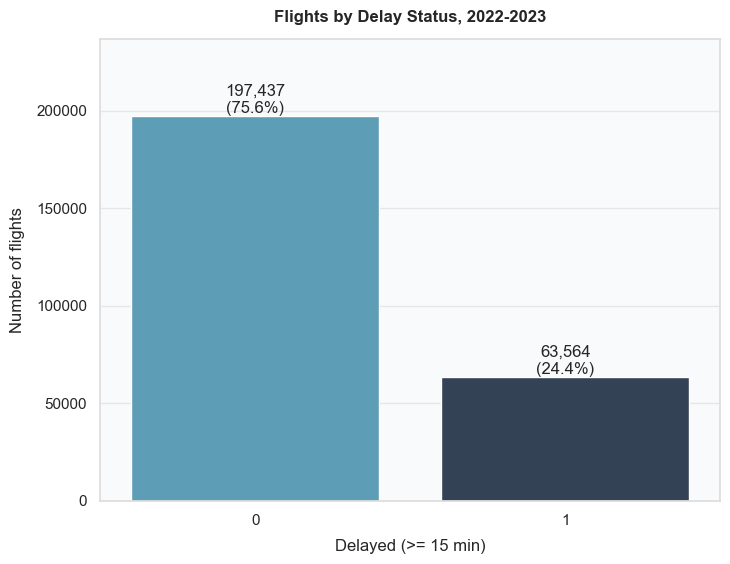

In [77]:
# Plot 'delayed_15'
# 1. Create a sample DataFrame and get value counts
counts = merged_df['delayed_15'].value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.barplot(x=counts.index, y=counts.values,
            palette=[palette[0], palette[1]])

plt.title("Flights by Delay Status, 2022-2023")
plt.xlabel("Delayed (>= 15 min)")
plt.ylabel("Number of flights")
plt.margins(y=0.20)

total = counts.sum()
for i, v in enumerate(counts.values):
    pct = v / total * 100
    plt.text(i, v, f"{v:,}\n({pct:.1f}%)",
             ha='center', va='bottom')

plt.show()

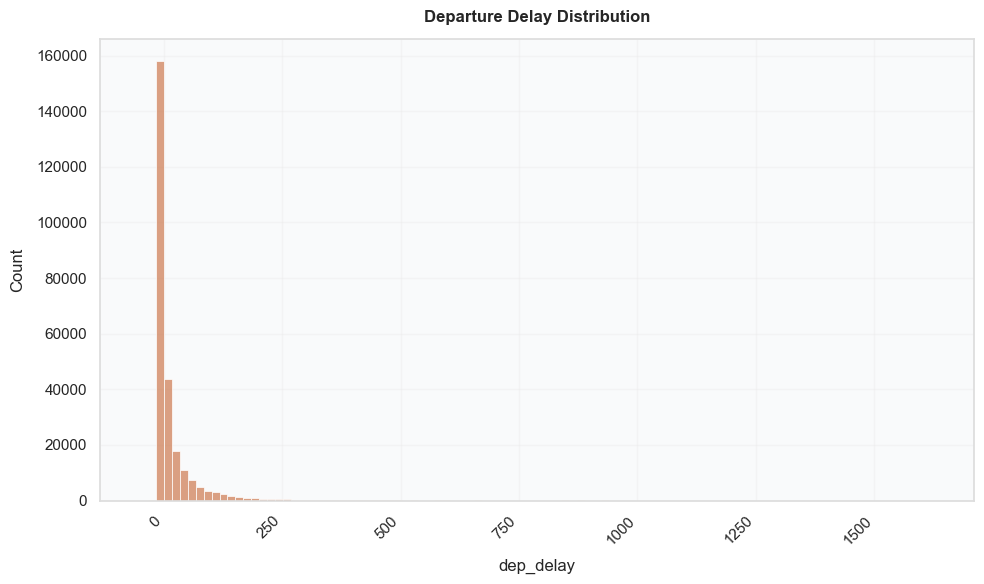

In [78]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(merged_df['dep_delay'], color=palette[4], bins=100)
plt.grid(alpha=0.3) #adds the grid
plt.xticks(rotation=45, ha='right') # Rotates the labels by 45 degrees
plt.title('Departure Delay Distribution')
plt.tight_layout()
plt.show()

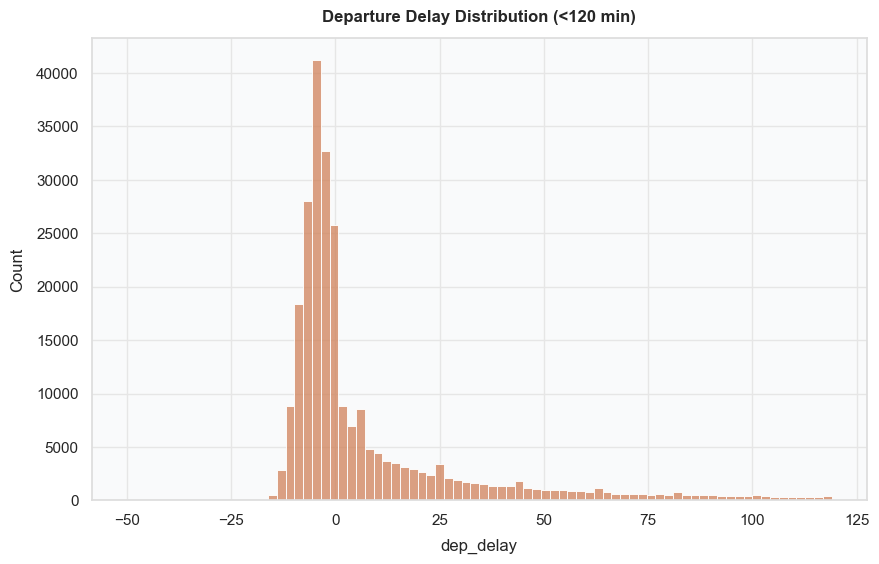

In [79]:
plt.figure(figsize=(10,6))
sns.histplot(
    merged_df.query("dep_delay < 120")['dep_delay'],
    bins=80,
    color=palette[4]
)
plt.title("Departure Delay Distribution (<120 min)")
plt.show()

In [80]:
# summary stats
merged_df['dep_delay'].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count    261001.000000
mean         16.535147
std          56.927069
min         -50.000000
50%          -2.000000
75%          14.000000
90%          58.000000
95%         106.000000
99%         241.000000
max        1627.000000
Name: dep_delay, dtype: float64

- Median flight leaves slightly early.
- 75% leave within 15 min.
- Extreme tail exists.

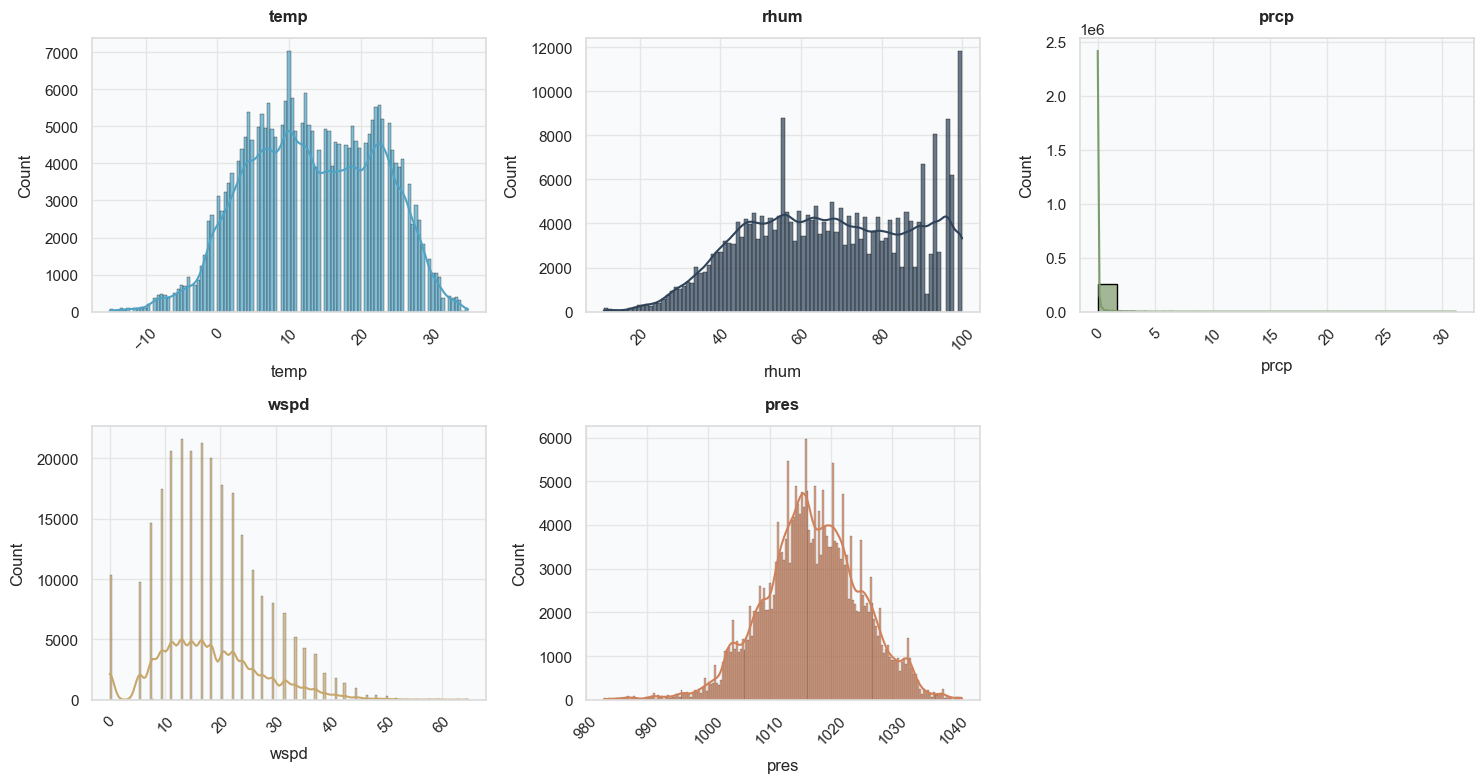

In [81]:
# Plot continuous weather features
n_cols = 3

n_rows = int(np.ceil(len(weather_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(weather_features):
    color = palette[i % len(palette)]
    
    sns.histplot(
        data=merged_df, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color=color, 
        alpha=0.7, 
        edgecolor="black"
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

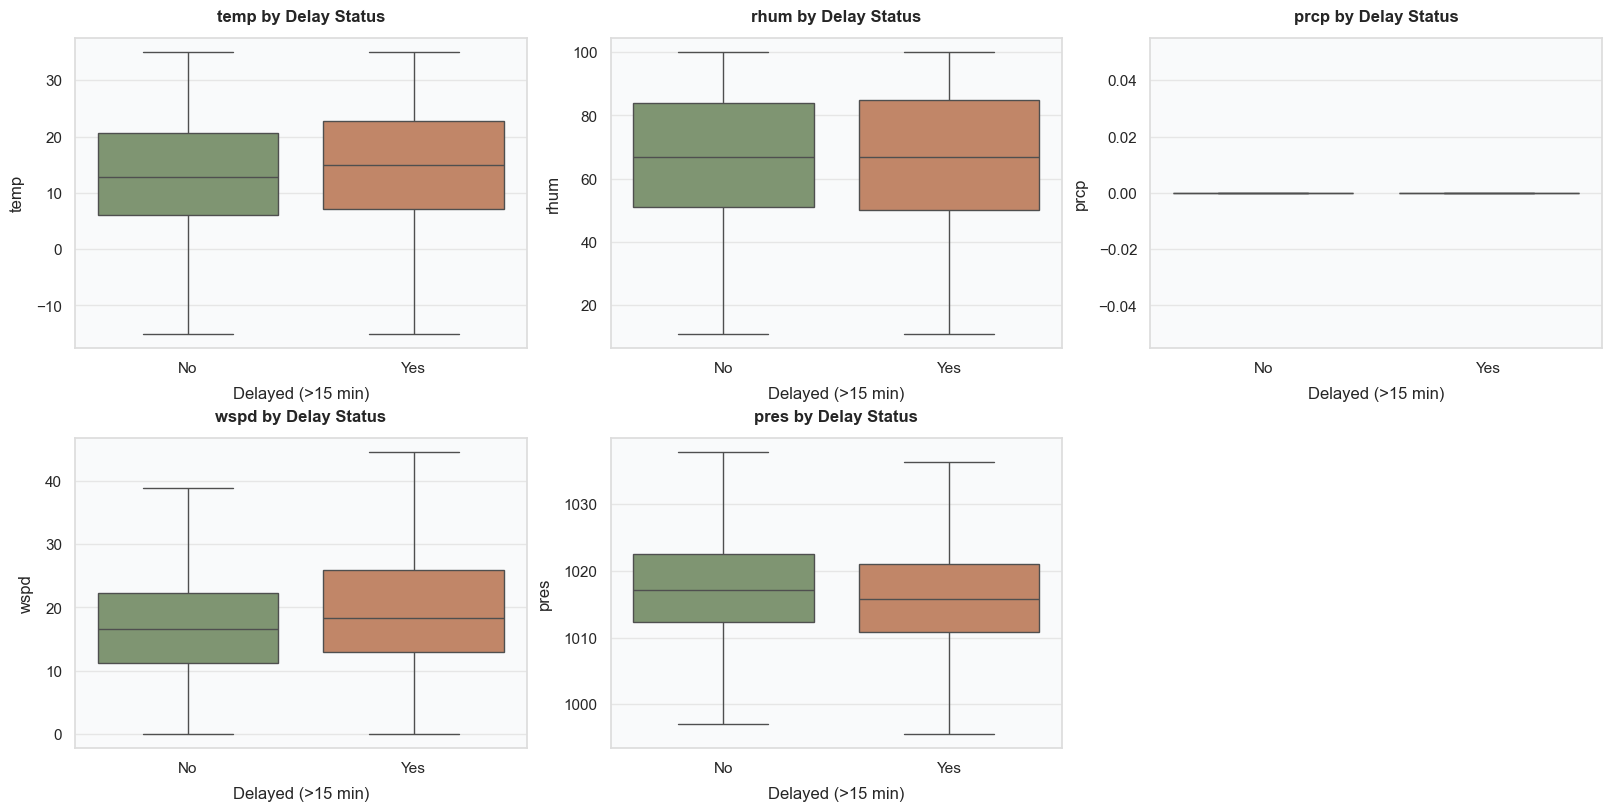

In [82]:
# Box plots with breakdown by class

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 8),
    constrained_layout=True
)

axes = axes.flatten()

for i, feature in enumerate(weather_features):
    sns.boxplot(
        data=merged_df,
        x='delayed_15',
        y=feature,
        #hue='delayed_15',  
        palette=[palette[2], palette[4]],
        ax=axes[i],
        showfliers=False  # important for heavy tails
    )
    axes[i].set_title(f"{feature} by Delay Status")
    axes[i].set_xlabel("Delayed (>15 min)")
    axes[i].set_xticklabels(["No", "Yes"])

# Remove unused subplot
fig.delaxes(axes[-1])

plt.show()

In [83]:

merged_df.groupby('delayed_15')[weather_features].median()

,temp,rhum,prcp,wspd,pres
delayed_15,,,,,
0,12.8,67.0,0.0,16.6,1017.1
1,15.0,67.0,0.0,18.4,1015.8


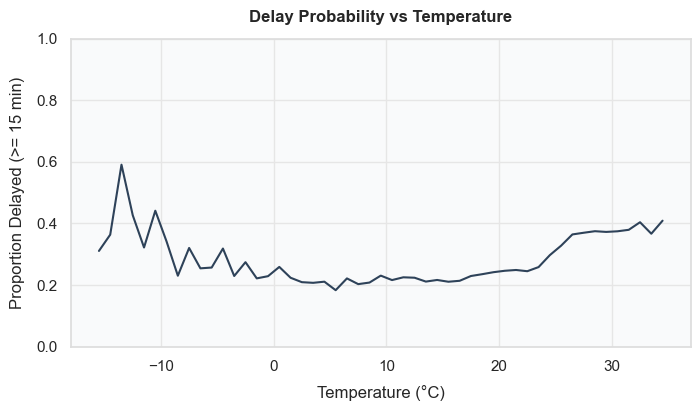

In [84]:
plot_df = merged_df[['temp','delayed_15']].copy()

# 1°C bins (adjust if you want smoother)
plot_df['temp_bin'] = pd.cut(plot_df['temp'], bins=np.arange(-20, 41, 1))

temp_rate = plot_df.groupby('temp_bin', observed=True)['delayed_15'].mean()
temp_mid = [interval.mid for interval in temp_rate.index]

plt.figure(figsize=(8,4))
plt.plot(temp_mid, temp_rate.values, color=palette[1])
plt.title("Delay Probability vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Proportion Delayed (>= 15 min)")
plt.ylim(0, 1)
plt.show()

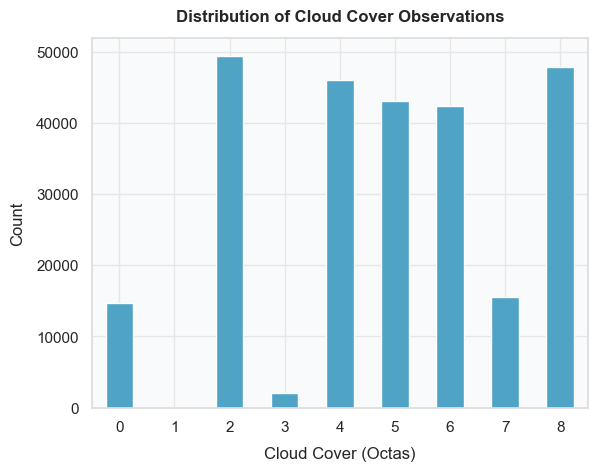

In [85]:
merged_df['cldc'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Cloud Cover Observations")
plt.xlabel("Cloud Cover (Octas)")
plt.ylabel("Count")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

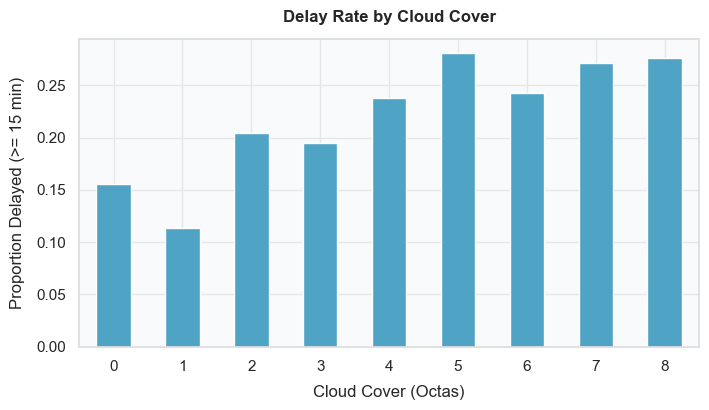

In [86]:
cldc_delay = (
    merged_df
    .groupby('cldc')['delayed_15']
    .mean()
)
cldc_delay.plot(kind='bar', figsize=(8,4))
plt.ylabel("Proportion Delayed (>= 15 min)")
plt.xlabel("Cloud Cover (Octas)")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.title("Delay Rate by Cloud Cover")
plt.show()

In [87]:
#Bin wind direction into compass sectors
merged_df['wdir_bin_eda'] = pd.cut(
    merged_df['wdir'],
    bins=[-0.1,45,90,135,180,225,270,315,360],
    labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
    include_lowest=True
)

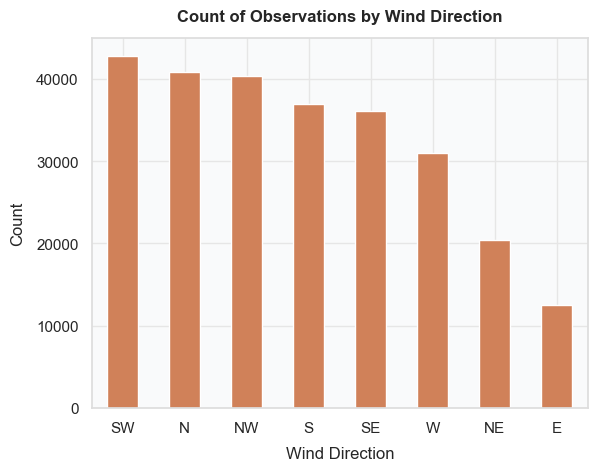

In [88]:
merged_df['wdir_bin_eda'].value_counts().plot(kind='bar', color=palette[4])
plt.title("Count of Observations by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Count")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

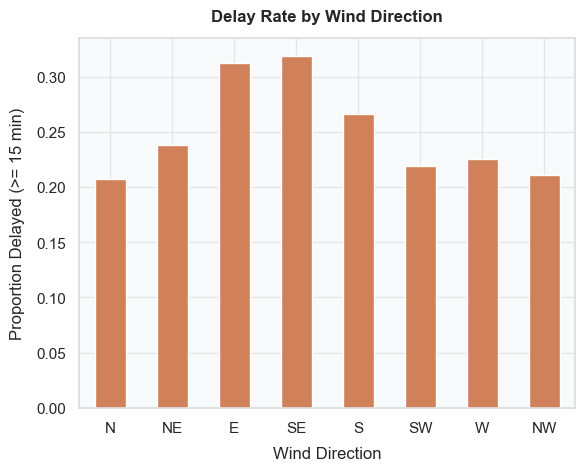

In [89]:
merged_df.groupby('wdir_bin_eda')['delayed_15'].mean().plot(kind='bar', color=palette[4])
plt.ylabel("Proportion Delayed (>= 15 min)")
plt.xlabel("Wind Direction")
plt.title("Delay Rate by Wind Direction")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

In [90]:
# Create the mapping dictionary for coco
weather_labels = {
    1:"Clear", 2:"Fair", 3:"Cloudy", 4:"Overcast",
    5:"Fog", 6:"Freezing Fog",
    7:"Light Rain", 8:"Rain", 9:"Heavy Rain",
    10:"Freezing Rain", 11:"Heavy Freezing Rain",
    12:"Sleet", 13:"Heavy Sleet",
    14:"Light Snowfall", 15:"Snowfall", 16:"Heavy Snowfall",
    17:"Rain Shower", 18:"Heavy Rain Shower",
    19:"Sleet Shower", 20:"Heavy Sleet Shower",
    21:"Snow Shower", 22:"Heavy Snow Shower",
    23:"Lightning", 24:"Hail",
    25:"Thunderstorm", 26:"Heavy Thunderstorm",
    27:"Storm"
}

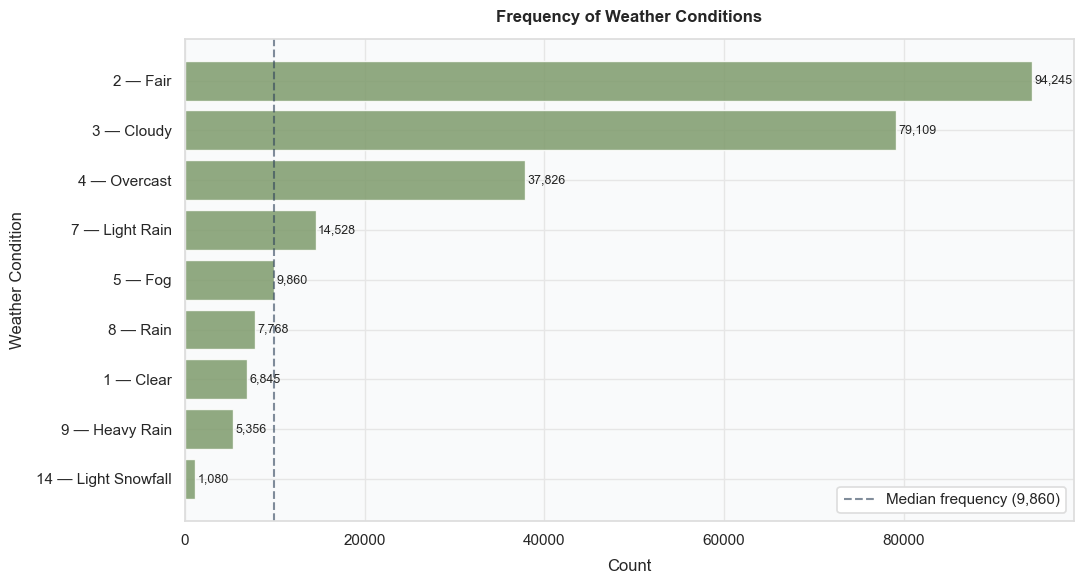

In [91]:
# Build labelled counts

min_n = 500

freq_df = (
    merged_df['coco']
    .value_counts()
    .drop(0)
    .sort_values()   # ascending for barh
    .rename("count")
    .to_frame()
    .assign(
        weather_label=lambda d:
        d.index.astype(str) + " — " + d.index.map(weather_labels)
    )
)

freq_df = freq_df[freq_df['count'] >= min_n]

plt.figure(figsize=(11,6))

bars = plt.barh(
    freq_df['weather_label'],
    freq_df['count'],
    color=palette[2],
    alpha=0.85
)

plt.title("Frequency of Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Weather Condition")

# annotate counts
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + freq_df['count'].max() * 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=9
    )

median_count = freq_df['count'].median()

plt.axvline(
    median_count,
    linestyle='--',
    linewidth=1.5,
    color='#2E4259',
    alpha=0.6,
    label=f'Median frequency ({int(median_count):,})'
)

legend = plt.legend(
    loc='lower right',
    frameon=True,
    fancybox=True,     # rounded corners
    framealpha=1,      # solid background
    edgecolor='#DDDDDD',
    facecolor='white',
    fontsize=11
)

legend.get_frame().set_linewidth(1.2)


plt.tight_layout()
plt.show()

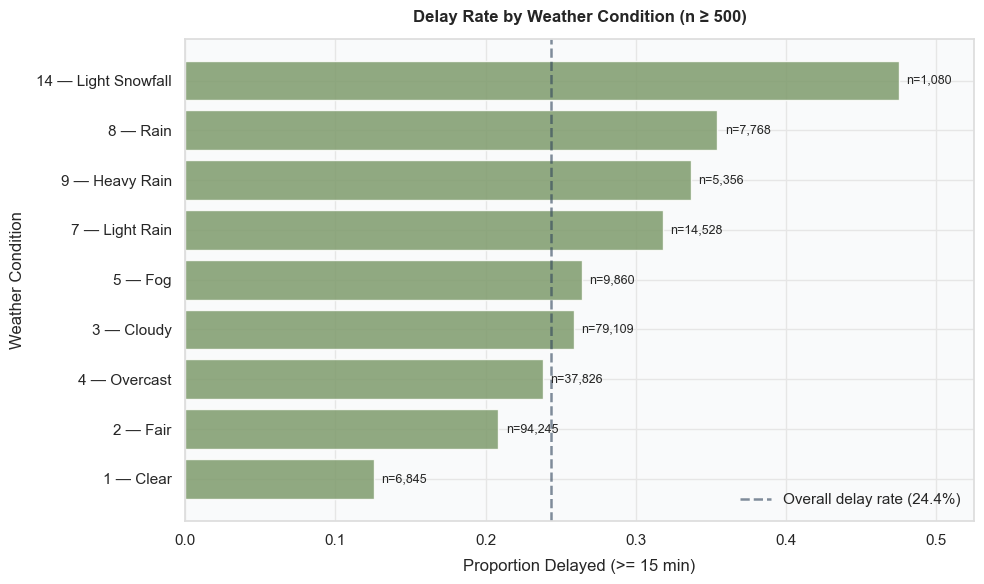

In [92]:
# Assume 'value_to_exclude' is the value you want to drop from the 'coco' column
value_to_exclude = 0

coco_summary = (
    merged_df[merged_df['coco'] != value_to_exclude] # Filter out the value
    .groupby('coco')
    .agg(delay_rate=('delayed_15','mean'),
         n=('delayed_15','size'))
    .sort_values('delay_rate', ascending=False)
)

# Keep top 12 by delay rate but require minimum n
min_n = 500
plot_df = coco_summary[coco_summary['n'] >= min_n].head(12)

# Map labels cleanly
plot_df = plot_df.assign(
    weather_label = plot_df.index.astype(str) + " — " + plot_df.index.map(weather_labels)
)

# Sort so highest delay is at the top
plot_df = plot_df.sort_values("delay_rate")

plt.figure(figsize=(10,6))

bars = plt.barh(
    plot_df['weather_label'],
    plot_df['delay_rate'],
    color=palette[2],
    alpha=0.85
)

plt.xlabel("Proportion Delayed (>= 15 min)")
plt.ylabel("Weather Condition")
plt.title(f"Delay Rate by Weather Condition (n ≥ {min_n})")

# annotate counts at end of bars
for bar, n in zip(bars, plot_df['n']):
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"n={int(n):,}",
        va='center',
        fontsize=9
    )

plt.xlim(0, min(1, plot_df['delay_rate'].max() + 0.05))

overall_rate = merged_df['delayed_15'].mean()

# reference line for the overall delay rate
overall_rate = merged_df['delayed_15'].mean()

plt.axvline(
    overall_rate,
    linestyle='--',
    linewidth=1.8,
    color=palette[1],
    alpha=0.6,
    label=f'Overall delay rate ({overall_rate:.1%})'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [93]:
merged_df['coco'].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count    261001.0
mean     3.333359
std      2.002793
min           0.0
50%           3.0
75%           4.0
90%           7.0
95%           8.0
99%           9.0
max          25.0
Name: coco, dtype: Float64

In [94]:
# What is the breakdown of weather code observations over 10?
coco_10 = merged_df[merged_df['coco'] >=10]
coco_10['coco'].value_counts(normalize=True)*100

coco
14         62.5
15    10.069444
12     9.085648
18      7.75463
16     5.266204
13     5.034722
10     0.115741
25     0.115741
17      0.05787
Name: proportion, dtype: Float64

In [95]:
merged_df.groupby("coco")["delayed_15"].mean().sort_values()

coco
17    0.000000
1     0.125785
2     0.208329
4     0.238222
3     0.258630
5     0.263895
12    0.267516
0     0.282120
7     0.318075
9     0.336632
8     0.354145
18    0.358209
16    0.362637
13    0.367816
14    0.475000
25    0.500000
15    0.551724
10    1.000000
Name: delayed_15, dtype: float64

<b>Observations:</b>
- The statistical summary performed on the continuous features indicate that various features differ in range greatly, e.g. Total Precipitation ranges from 0 to 31.2, with the median being 0, whilst Air Pressure (MSL) ranges from 982.9 to 1041.4. Depending on the model, we need to scale our data.
- the proportion of delayed flights in the train dataset is 24.4%
- We can see from the above that there is no drastic difference in average weather conditions between delayed and non-delayed flights. Differences exist but are modest.
- The temperatures range from -15 to 35 degrees Celsius. Our data indicates that there could be an increased probability of flights being delayed as the temperature drops or rises.
- flights departing under high cloud cover (7–8 octas) experience an approximately 10–12 percentage-point higher probability of departure delay (>15 minutes) compared to clear-sky conditions.
- probability of departure delay increases with the eastern and south-eastern winds. For our location, JFK, Eastern and north-eastern winds are often associated with coastal systems, storms, nor’easters.
- With the weather conditions code, 99% of observations range from Clear to Heavy Rain. Within the remaining 1% is 62% of the observations are Light Snowfall and we can see that flights departing under this weather code condition experience an approximately 12-13 percentage-point higher probability of departure delay (>15 minutes) compared to other weather conditions.
- The absence of other Weather Condition Codes is most likely linked to the fact that severe weather conditions don’t just cause delays but cancellations.

In [96]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261001 entries, 0 to 261000
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   flight_date          261001 non-null  object        
 1   tail_num             261001 non-null  object        
 2   op_carrier_fl_num    261001 non-null  int64         
 3   origin_airport_id    261001 non-null  int64         
 4   origin               261001 non-null  object        
 5   dest_airport_id      261001 non-null  int64         
 6   dest                 261001 non-null  object        
 7   crs_dep_time         261001 non-null  object        
 8   dep_time             261001 non-null  object        
 9   dep_delay            261001 non-null  int64         
 10  cancelled            261001 non-null  float64       
 11  diverted             261001 non-null  float64       
 12  carrier_delay        261001 non-null  float64       
 13  weather_delay 

<h2>4. Prepare the Data and Export</h2>

- Deal with the data as required by the modelling technique
    - **Outliers** (remove or adjust if possible or necessary)
    - **Null** (remove or interpolate if possible or necessary)
    - **Missing Values** (remove or interpolate if possible or necessary)
    - **Coded content** (transform if possible or necessary [str to number or vice-versa])
    - **Feature Engineer** (if useful or necessary)

In [97]:
""" 
Sine and cosine transformations are used to convert angular wind direction data (\(0^{\circ }-360^{\circ }\)) into continuous Cartesian components (U and V). 
This transformation is essential in meteorology and data science to avoid the discontinuity at \(360^{\circ }/0^{\circ }\) (where values are numerically far apart but physically close). 
"""
# sine/cosine transformations for wind direction 
merged_df['wdir_rad'] = np.deg2rad(merged_df['wdir'])
merged_df['wdir_sin'] = np.sin(merged_df['wdir_rad'])
merged_df['wdir_cos'] = np.cos(merged_df['wdir_rad'])

In [98]:
merged_df

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,wspd,pres,cldc,coco,cldc_missing,delayed_15,wdir_bin_eda,wdir_rad,wdir_sin,wdir_cos
0,1/1/2022 0:00,N2047J,1603,12478,JFK,14843,SJU,0540,0954,254,...,13.0,1013.0,8,4,0,1,SE,3.141593,-0.0,-1.0
1,1/1/2022 0:00,N521JB,225,12478,JFK,15304,TPA,0600,0605,5,...,13.0,1013.0,8,4,0,0,SE,3.141593,-0.0,-1.0
2,1/1/2022 0:00,N969NN,2643,12478,JFK,11057,CLT,0600,0635,35,...,13.0,1013.0,8,4,0,1,SE,3.141593,-0.0,-1.0
3,1/1/2022 0:00,N4058J,23,12478,JFK,12892,LAX,0600,0619,19,...,13.0,1013.0,8,4,0,1,SE,3.141593,-0.0,-1.0
4,1/1/2022 0:00,N858NW,424,12478,JFK,10397,ATL,0610,0747,97,...,13.0,1013.0,8,4,0,1,SE,3.141593,-0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260996,12/31/2023 12:00:00 AM,N957JB,1803,12478,JFK,14843,SJU,2129,2120,-9,...,18.4,1014.9,6,3,0,0,W,4.886922,-0.984808,0.173648
260997,12/31/2023 12:00:00 AM,N566JB,1053,12478,JFK,14027,PBI,2150,2243,53,...,18.4,1015.4,7,3,0,1,SW,4.712389,-1.0,0.0
260998,12/31/2023 12:00:00 AM,N994JL,403,12478,JFK,14843,SJU,2255,2345,50,...,11.2,1015.8,6,3,0,1,W,5.410521,-0.766045,0.642788
260999,12/31/2023 12:00:00 AM,N793JB,745,12478,JFK,14254,PSE,2259,2248,-11,...,11.2,1015.8,6,3,0,0,W,5.410521,-0.766045,0.642788


In [99]:
print("cldc missing:", merged_df['cldc'].isna().sum())
print("coco missing:", merged_df['coco'].isna().sum())
print("coco unique min/max:", merged_df['coco'].min(), merged_df['coco'].max())
print(merged_df['coco'].value_counts().head(10)) #0 is now my “Unknown” category; valid codes start at 1.

cldc missing: 0
coco missing: 0
coco unique min/max: 0 25
coco
2     94245
3     79109
4     37826
7     14528
5      9860
8      7768
1      6845
9      5356
0      3736
14     1080
Name: count, dtype: Int64


In [100]:
# Final pre-export sanity checklist
print(merged_df.shape)
print(merged_df.info())

(261001, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261001 entries, 0 to 261000
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   flight_date          261001 non-null  object        
 1   tail_num             261001 non-null  object        
 2   op_carrier_fl_num    261001 non-null  int64         
 3   origin_airport_id    261001 non-null  int64         
 4   origin               261001 non-null  object        
 5   dest_airport_id      261001 non-null  int64         
 6   dest                 261001 non-null  object        
 7   crs_dep_time         261001 non-null  object        
 8   dep_time             261001 non-null  object        
 9   dep_delay            261001 non-null  int64         
 10  cancelled            261001 non-null  float64       
 11  diverted             261001 non-null  float64       
 12  carrier_delay        261001 non-null  float64       
 13  w

In [102]:
# Export the merged_df for modelling in the another notebook 
merged_df.to_csv("data/merged_df_2022_2023.csv", index=False)